In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Necessary for the entire / most of the development lifecycle
import pandas as pd
import numpy as np
import sklearn as skl
from sklearn.model_selection import train_test_split #Import libraries for data spliting

import seaborn as sns #import libraries for Exploratoratory data analysis
import missingno as msno
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler #import preprocessing libraries
from sklearn.preprocessing import StandardScaler

#build model
from sklearn.linear_model import Lasso
from sklearn import metrics

#libraries to evaluate model evaluation
from sklearn.metrics import \
  r2_score, mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/Car details v3.csv')
#pd.read_csv is a function used to read the dataset which is in CSV format and converts the csv file to a pandas dataframe 'df'.

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
df.columns
#show columns in dataframe

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [ ]:
df.info()

#show basic information in dataframe.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [ ]:
#df.shape

In [ ]:
#df.describe()

#display descriptive statistics about dataframe. 

In [ ]:
df = df.drop(columns=['torque'])

#drop torque column from dataframe

In [ ]:
df["mileage_kmpl"] = df["mileage"].str.split(" ").str[0].astype(float)
df["engine_cc"] = df["engine"].str.split(" ").str[0].astype(float)
df["max_power"] = df["max_power"].str.split(" ").str[0]
df['max_power_bhp'] = pd.to_numeric(df['max_power'], errors='coerce') 
df.drop("mileage", axis=1, inplace=True)
df.drop("engine", axis=1, inplace=True)
df.drop("max_power", axis=1, inplace=True)

#Convert object datatypes to int/float and rename mileage, engine and max power columns.

In [ ]:
df[['brand','model']] = df['name'].str.split(' ', n=1, expand=True)
df = df.drop(columns = ['name'])

#split name column to brand and model and drop name column.

In [ ]:
df.dtypes

#'dtypes' returns the datatype of each column in 'df'

year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
seats            float64
mileage_kmpl     float64
engine_cc        float64
max_power_bhp    float64
brand             object
model             object
dtype: object

In [ ]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,Maruti,Swift Dzire VDI
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,Skoda,Rapid 1.5 TDI Ambition
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,Honda,City 2017-2020 EXi
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00,Hyundai,i20 Sportz Diesel
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20,Maruti,Swift VXI BSIII


In [ ]:
df = df.dropna()

In [ ]:
df.shape

(7906, 13)

In [ ]:
#Splitting a dataset into training, validation, and testing sets is a technique in 
#machine learning to evaluate the performance of a model and prevent 
#overfitting, separate the features and the target variable

X = df.drop("selling_price", axis=1)
Y = df["selling_price"]

# split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

# further split the training set into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

print(f"X_train\nShape: {X_train.shape}\n\nX_test\nShape: {X_test.shape}\n")
print(f"X_val\nShape: {X_val.shape}\n\nY_val\nShape: {Y_val.shape}\n")
print(f"Y_train\nShape: {Y_train.shape}\n\nY_test\nShape: {Y_test.shape}\n")

X_train
Shape: (6403, 12)

X_test
Shape: (791, 12)

X_val
Shape: (712, 12)

Y_val
Shape: (712,)

Y_train
Shape: (6403,)

Y_test
Shape: (791,)



In [ ]:
df_train = pd.merge(X_train, Y_train, left_index=True, right_index=True)
df_train.head()


#merge x_train (attributes) and y_train(target/ground truth)

,year,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model,selling_price
5479,2017,60000,Diesel,Individual,Manual,First Owner,5.0,28.40,1248.0,74.02,Maruti,Swift Dzire VDI,669000
4289,2016,90000,Diesel,Individual,Manual,First Owner,5.0,19.09,1405.0,69.01,Tata,Indigo CS LS (TDI) BS-III,370000
3327,2011,65000,Petrol,Individual,Manual,Second Owner,5.0,18.90,998.0,67.10,Maruti,Wagon R AX BSIV,250000
6629,2019,80000,Diesel,Individual,Manual,First Owner,2.0,0.00,2523.0,70.00,Mahindra,Bolero Pik-Up CBC 1.7T,722000
3917,2018,30000,Diesel,Individual,Manual,First Owner,5.0,21.50,1497.0,108.50,Tata,Nexon 1.5 Revotorq XM,749000


In [ ]:
df_train.shape


(6403, 13)

In [ ]:
df_train.columns

#show columns in dataframe

Index(['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner',
       'seats', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'brand', 'model',
       'selling_price'],
      dtype='object')

In [ ]:
df_train.info()

#show basic information in dataframe.

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6403 entries, 5479 to 6602
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6403 non-null   int64  
 1   km_driven      6403 non-null   int64  
 2   fuel           6403 non-null   object 
 3   seller_type    6403 non-null   object 
 4   transmission   6403 non-null   object 
 5   owner          6403 non-null   object 
 6   seats          6403 non-null   float64
 7   mileage_kmpl   6403 non-null   float64
 8   engine_cc      6403 non-null   float64
 9   max_power_bhp  6403 non-null   float64
 10  brand          6403 non-null   object 
 11  model          6403 non-null   object 
 12  selling_price  6403 non-null   int64  
dtypes: float64(4), int64(3), object(6)
memory usage: 958.4+ KB


In [ ]:
df_train.describe()

#display descriptive statistics about dataframe. 

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,selling_price
count,6403.000000,6.403000e+03,6403.000000,6403.000000,6403.000000,6403.000000,6.403000e+03
mean,2013.994065,6.905637e+04,5.425269,19.397828,1463.222552,91.704456,6.433821e+05
std,3.844318,5.150743e+04,0.962349,4.051641,504.878238,35.580534,7.921996e+05
min,1994.000000,1.000000e+00,2.000000,0.000000,624.000000,32.800000,2.999900e+04
25%,2012.000000,3.500000e+04,5.000000,16.780000,1197.000000,68.050000,2.700000e+05
50%,2015.000000,6.000000e+04,5.000000,19.300000,1248.000000,82.000000,4.519990e+05
75%,2017.000000,9.500000e+04,5.000000,22.320000,1582.000000,102.000000,6.900000e+05
max,2020.000000,1.500000e+06,10.000000,42.000000,3604.000000,400.000000,1.000000e+07


**Exploratory Data Analysis**


Univariate Analysis

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


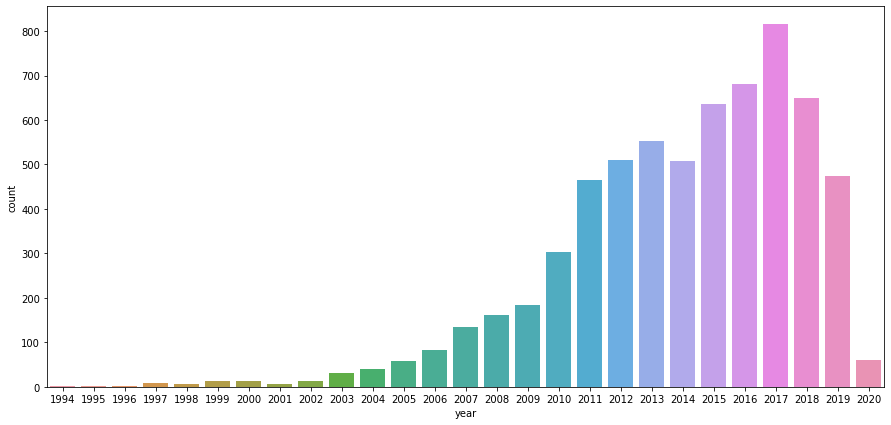

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['year'])

#countplot for year of manufacture. 
#shows the frequency of used cars produced each year. We can deduce that cars were produced more in the 2010s compared to other decades. 
#There might be different reason why there is this occurrence including increased demand of cars and advancements in technology. 
#Also, from the figure above, 2017 had the most cars produced between 1990s and 2020s.

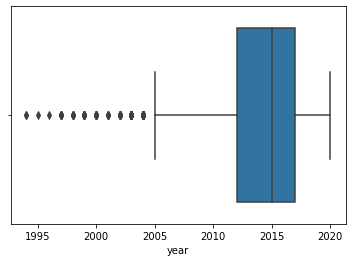

In [ ]:
sns.boxplot(data=df_train, x="year")
#boxplot for year of manufacture. 
#This shows that majority of the car production occured between 2010 and 2020.

km_driven

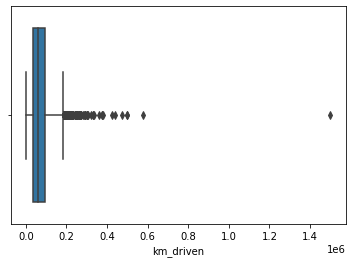

In [ ]:
sns.boxplot(data=df_train, x="km_driven")
#boxplot for kilometres driven.
# shows the distribution of used cars kilometres driven
# we can see that majority of the data lies between 0.0 and 0.2

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


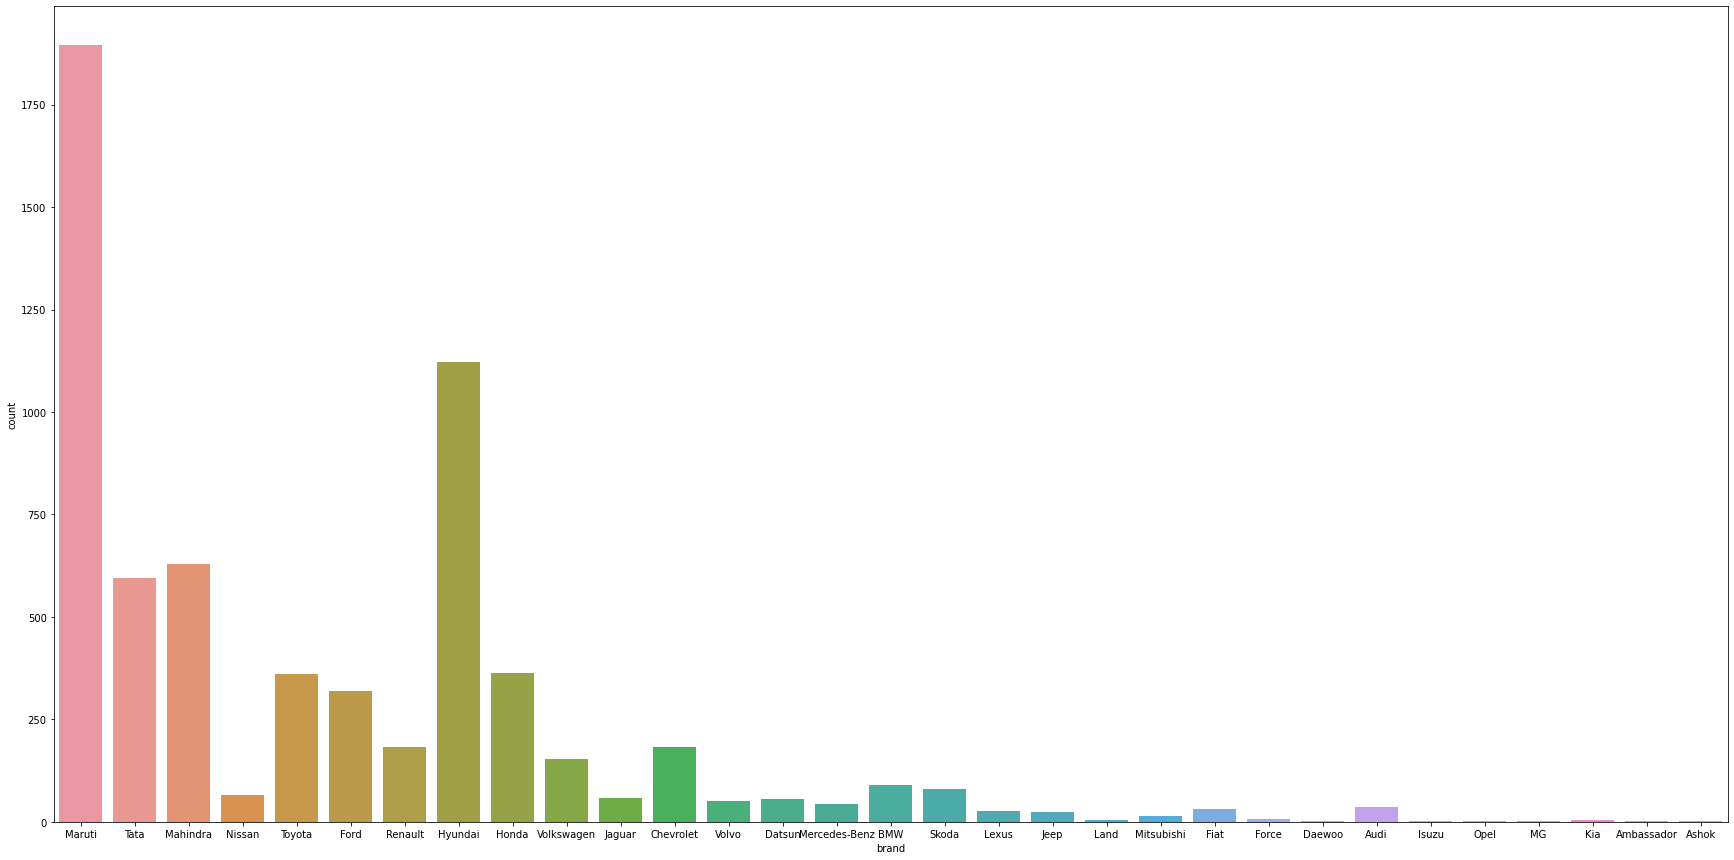

In [ ]:
plt.figure(figsize = (30,15))
sns.countplot(df_train['brand'])
plt.show()
#countplot for brand shows the distrubution of brands and maruti has the most cars followed by hyundai.

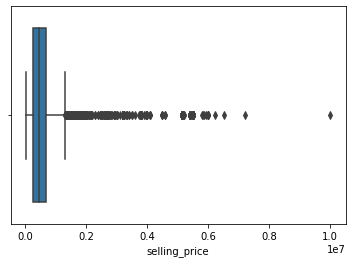

In [ ]:
sns.boxplot(data=df_train, x="selling_price")
#countplot for selling prie

Fuel type

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


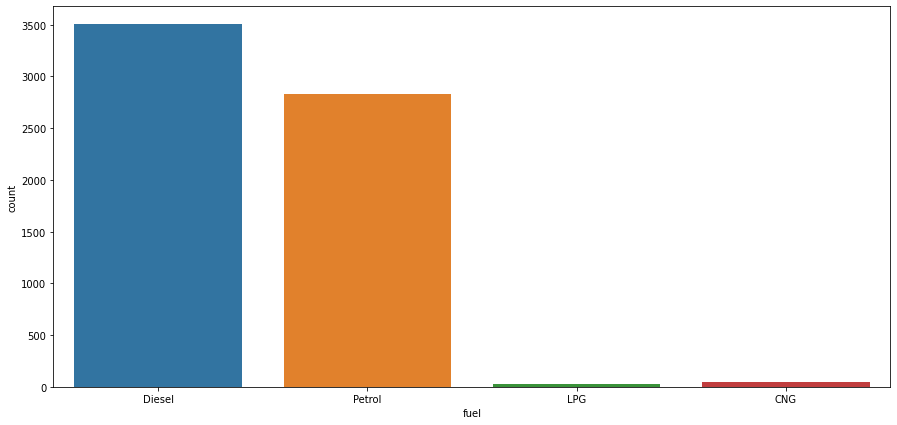

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['fuel'])
plt.show()

#The plot shows there are more diesel used cars in the dataset followed by petrol.
#This is self explanatory because these are the 2 most common type of cars.

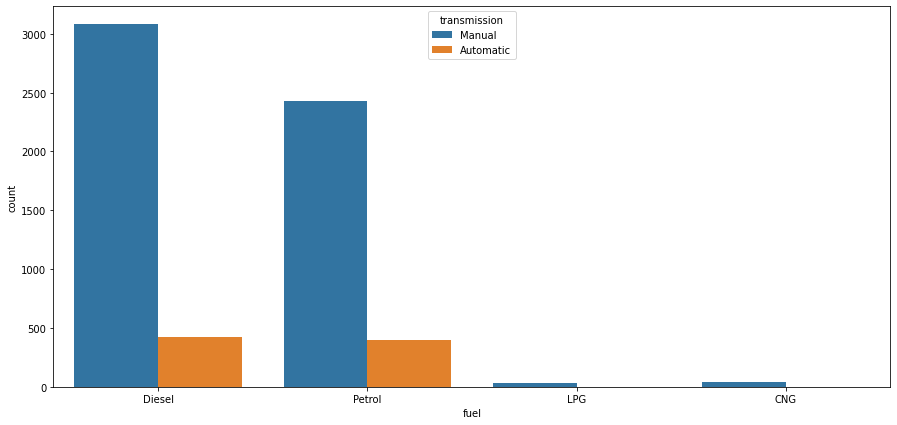

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(data=df_train, x='fuel', hue="transmission")
# This dplot shows there are manual transmission cars that run on diesel compared to other.

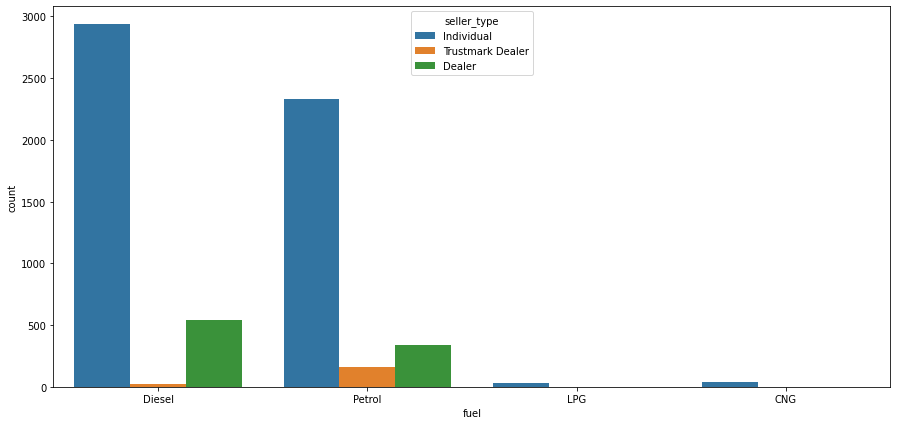

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(data=df_train, x='fuel', hue="seller_type")
#This plot shows that most cars are sold by individuals.

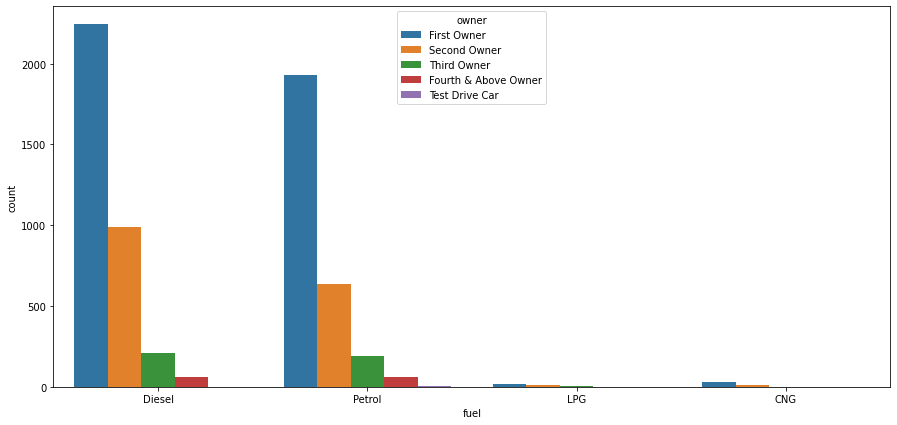

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(data=df_train, x='fuel', hue="owner")
#This plot shows that majority of the cars based on fuel type are previously owned by 1 owner.

Seller Type

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


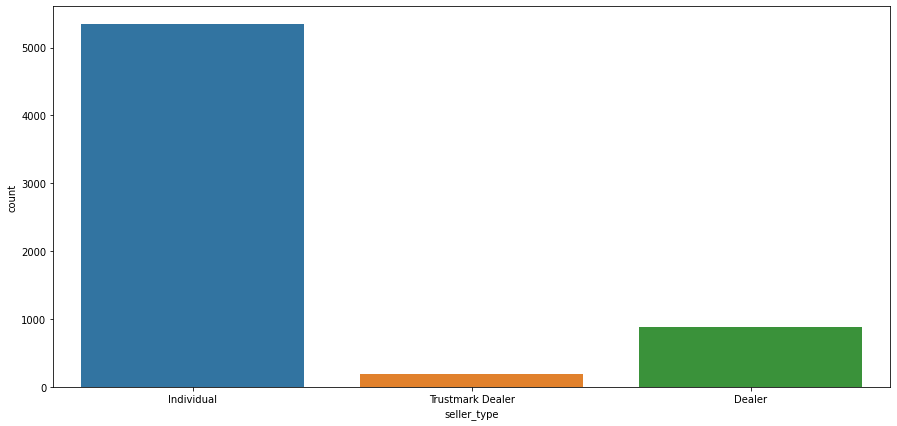

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['seller_type'])
#This plot shows most of the cars sold on cardekho are sold by individuals.

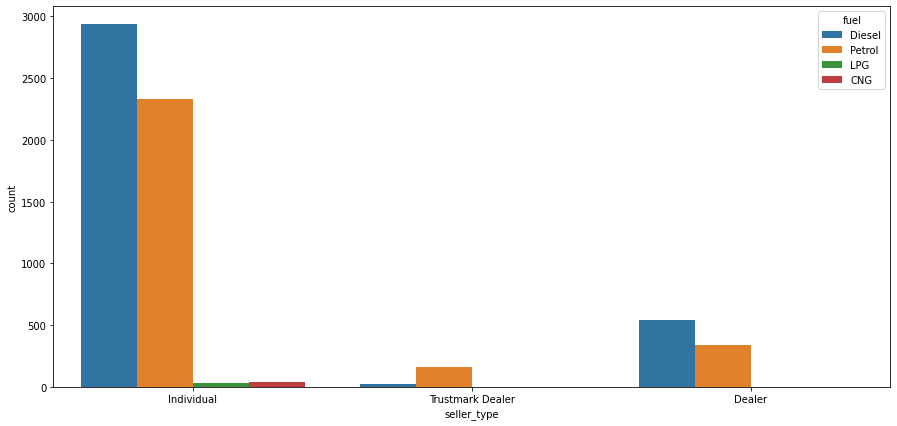

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(data=df_train, x='seller_type', hue="fuel")
#Shows that cars sold by individuals and dealers mainly run on diesel, while majority of cars sold by trustmark dealers run on petrol.

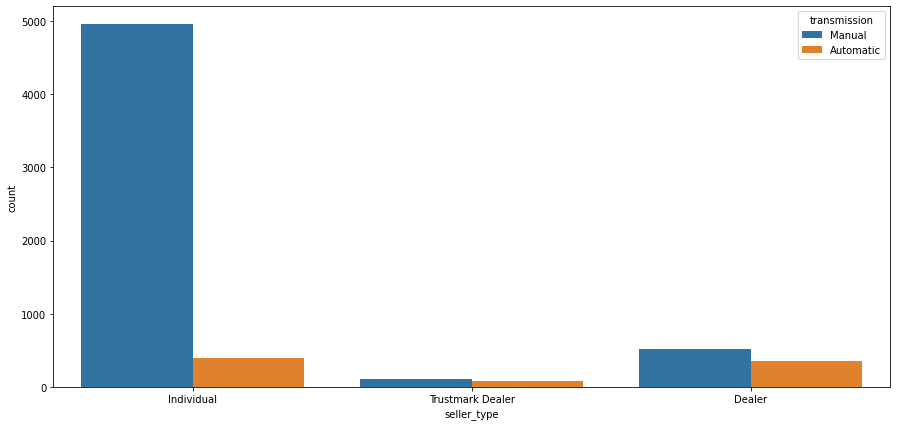

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(data=df_train, x='seller_type', hue="transmission")
#shows that cars sold by the sellers uses manual transmission.

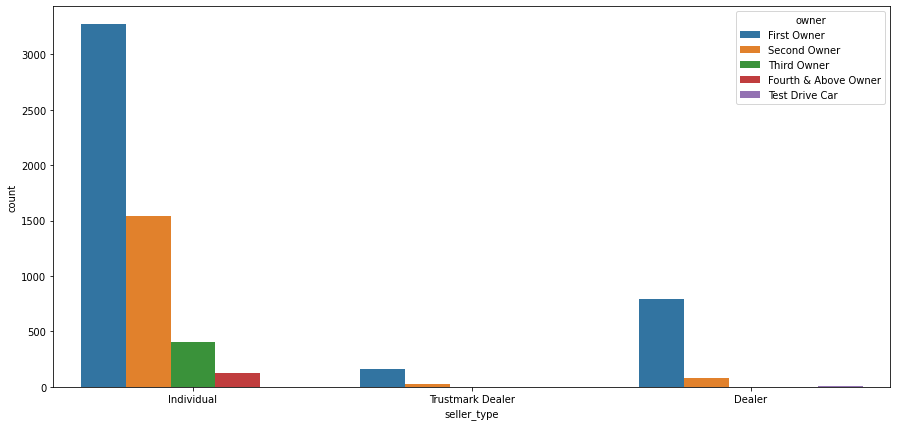

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(data=df_train, x='seller_type', hue="owner")
#this plot shows that most of the cars sold by sellers types are previously owned by 1 owner.

Transmission

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


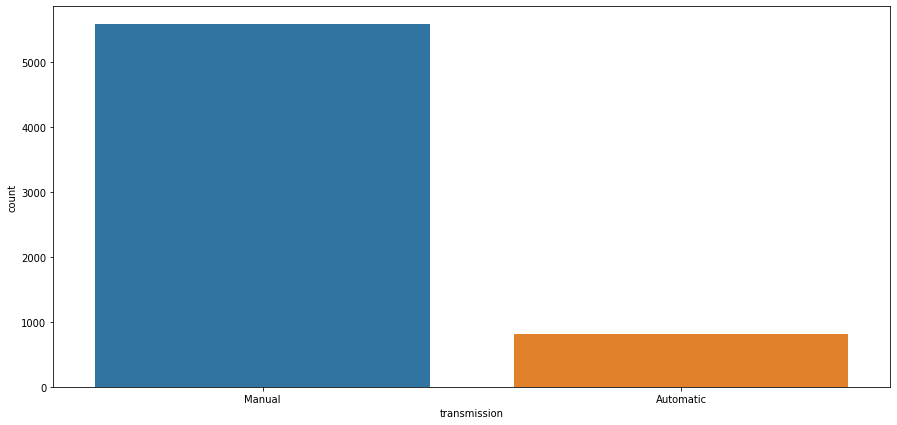

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['transmission'])

#Shows that most of the cars in the data uses manual transmissions.

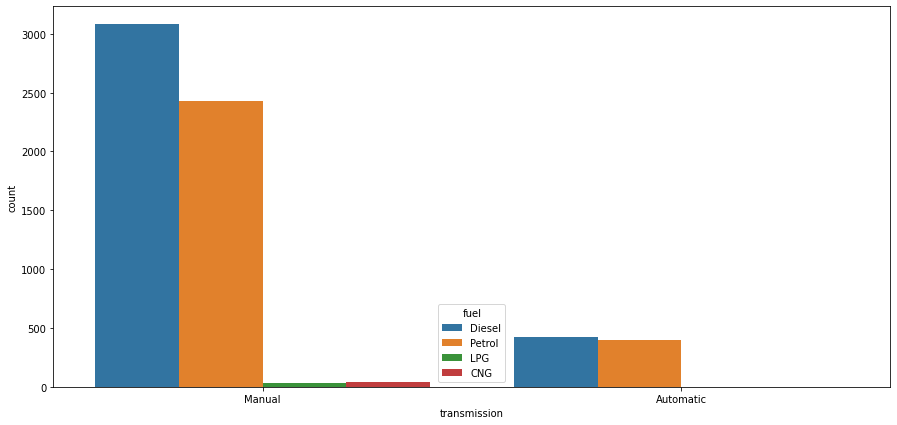

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(data=df_train, x='transmission', hue="fuel")
#shows that majority of manual and automatic cars run on diesel

owner

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


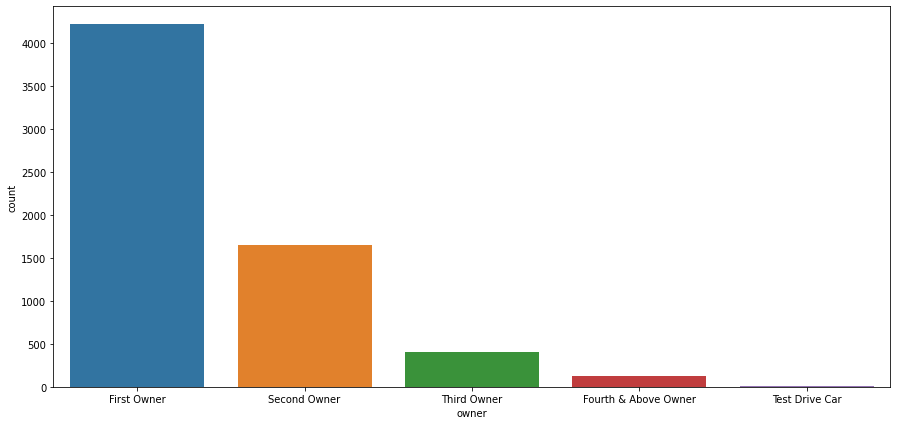

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['owner'])

#Majority of the cars sold were previously owned once.

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


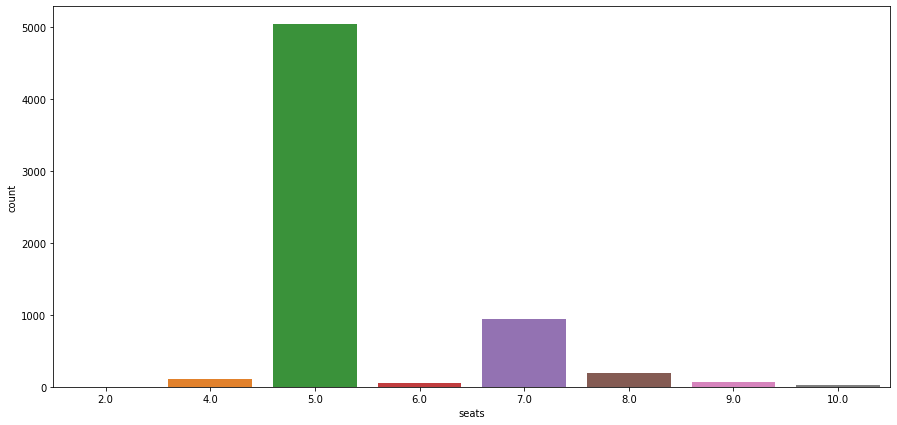

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['seats'])

#shows that most of the cars in the data are 5 seaters.

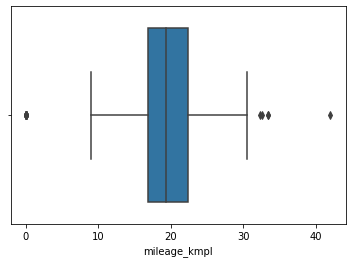

In [ ]:
sns.boxplot(data=df_train, x="mileage_kmpl")

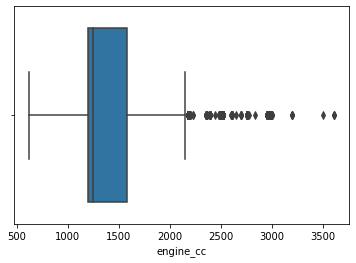

In [ ]:
sns.boxplot(data=df_train, x="engine_cc")

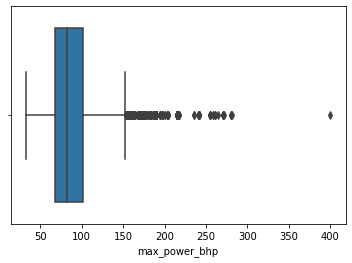

In [ ]:
sns.boxplot(data=df_train, x="max_power_bhp")

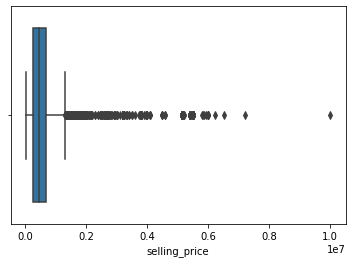

In [ ]:
sns.boxplot(data=df_train, x="selling_price")

Bivariate Analysis

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


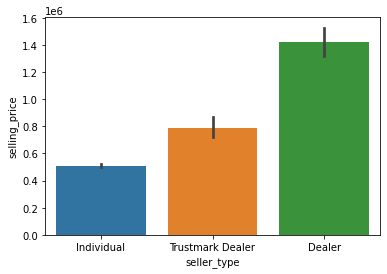

In [ ]:
sns.barplot('seller_type','selling_price',data=df_train)
# price vs seller type
# This plot shows that cars sold by dealers are priced higher.
# Cars sold by dealers are priced higher than those sold by individuals/trademark dealer, as dealerships have more resources and expertise to price the cars accurately.

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


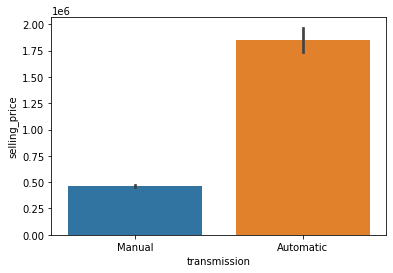

In [ ]:
sns.barplot('transmission','selling_price',data=df_train)
#transmission vs selling price
# Automatic cars are priced higher than manual cars because 
# cars with automatic transmissions tend to be more expensive than those with
# manual transmissions, due to the additional technology and components required to make them work.

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


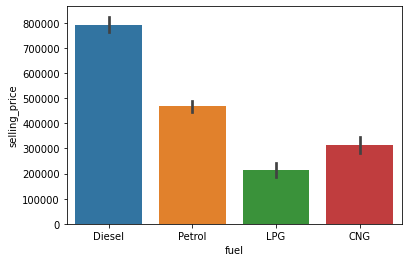

In [ ]:
sns.barplot('fuel','selling_price',data=df_train)
#fuel vs selling price

#Cars that run on diesel tend to be more expensive because of diesel's ability to manage fuel efficiently.

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


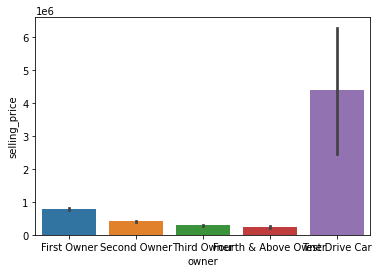

In [ ]:
sns.barplot('owner','selling_price',data=df_train)
#owner vs selling price


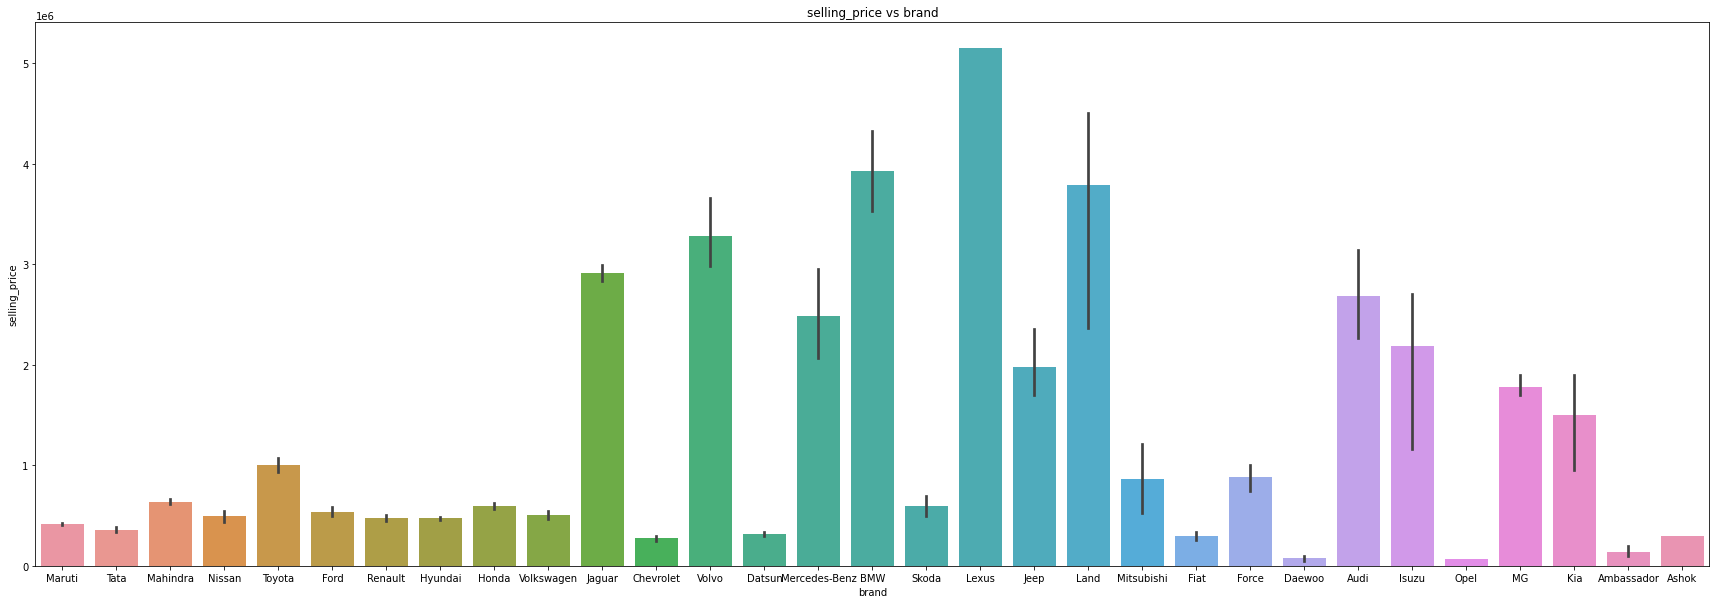

In [ ]:
plt.figure(figsize=(30,10))
plt.title("selling_price vs brand")
sns.barplot(data= df_train, x="brand", y="selling_price")

# shows that the most expensive brand is Lexus followed by BMW. and the least expensive brand 
# is Daewoo abd Opel this can be caused by different factors including mileage, engine size etc..

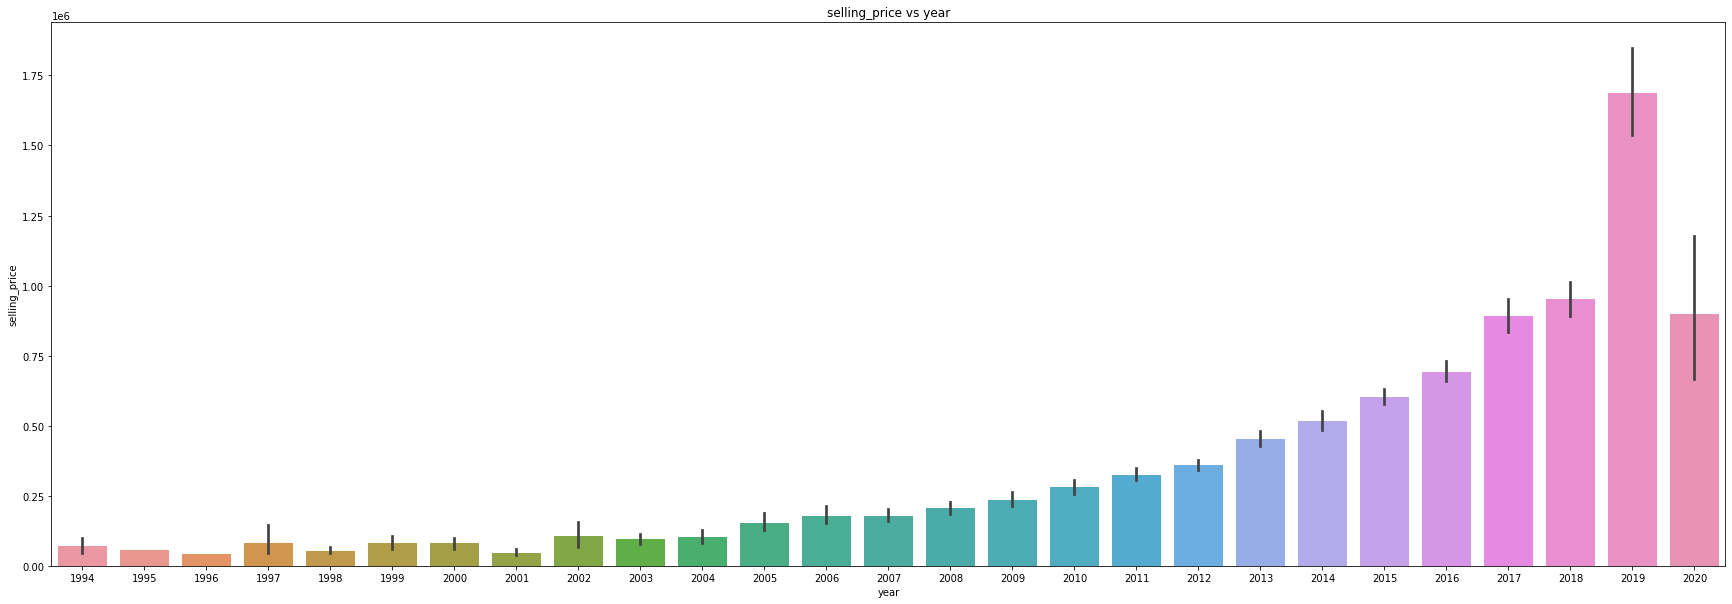

In [ ]:
plt.figure(figsize=(30,10))
plt.title("selling_price vs year")
sns.barplot(data= df_train, x="year", y="selling_price")

Text(0, 0.5, 'km_driven')

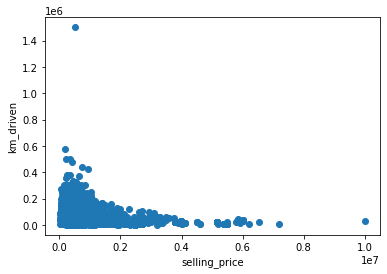

In [ ]:
x = df_train['selling_price']
y = df_train['km_driven']
plt.scatter(x, y)
plt.xlabel('selling_price')
plt.ylabel('km_driven')

#  This shows that the higher kilometres driven the lower the price.

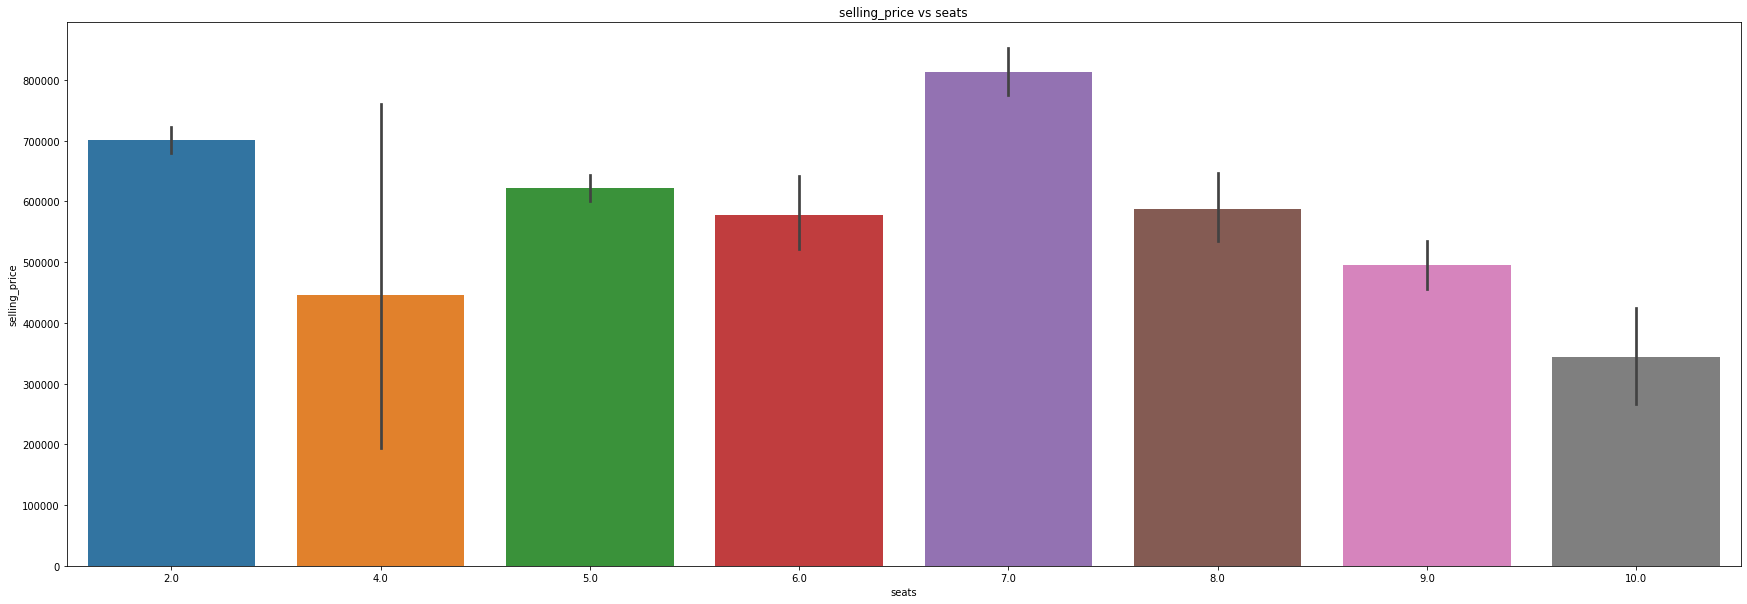

In [ ]:
plt.figure(figsize=(30,10))
plt.title("selling_price vs seats")
sns.barplot(data= df_train, x="seats", y="selling_price")
#shows that 7 seater cars are the most expensive cars in the dataset

Text(0, 0.5, 'selling_price')

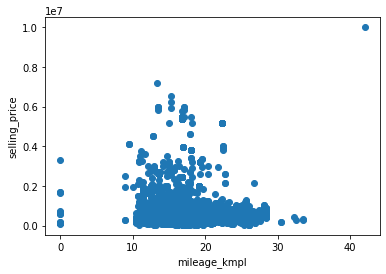

In [ ]:
x = df_train['mileage_kmpl']
y = df_train['selling_price']
plt.scatter(x, y)
plt.xlabel('mileage_kmpl')
plt.ylabel('selling_price')
# shows the lower the mileage the higher the price.

Text(0, 0.5, 'selling_price')

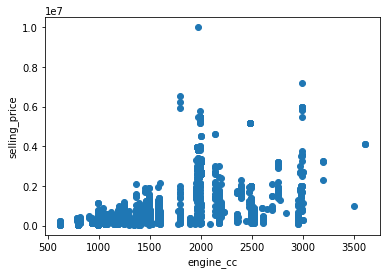

In [ ]:
x = df_train['engine_cc']
y = df_train['selling_price']
plt.scatter(x, y)
plt.xlabel('engine_cc')
plt.ylabel('selling_price')
# this shows that the higher the engine size the higher the selling price.

Text(0, 0.5, 'selling_price')

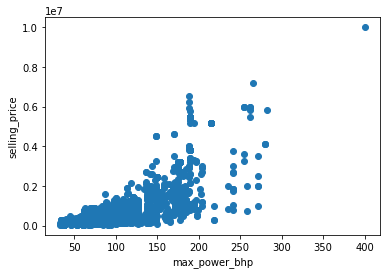

In [ ]:
x = df_train['max_power_bhp']
y = df_train['selling_price']
plt.scatter(x, y)
plt.xlabel('max_power_bhp')
plt.ylabel('selling_price')
# this shows that the higher the max power size the higher the selling price.

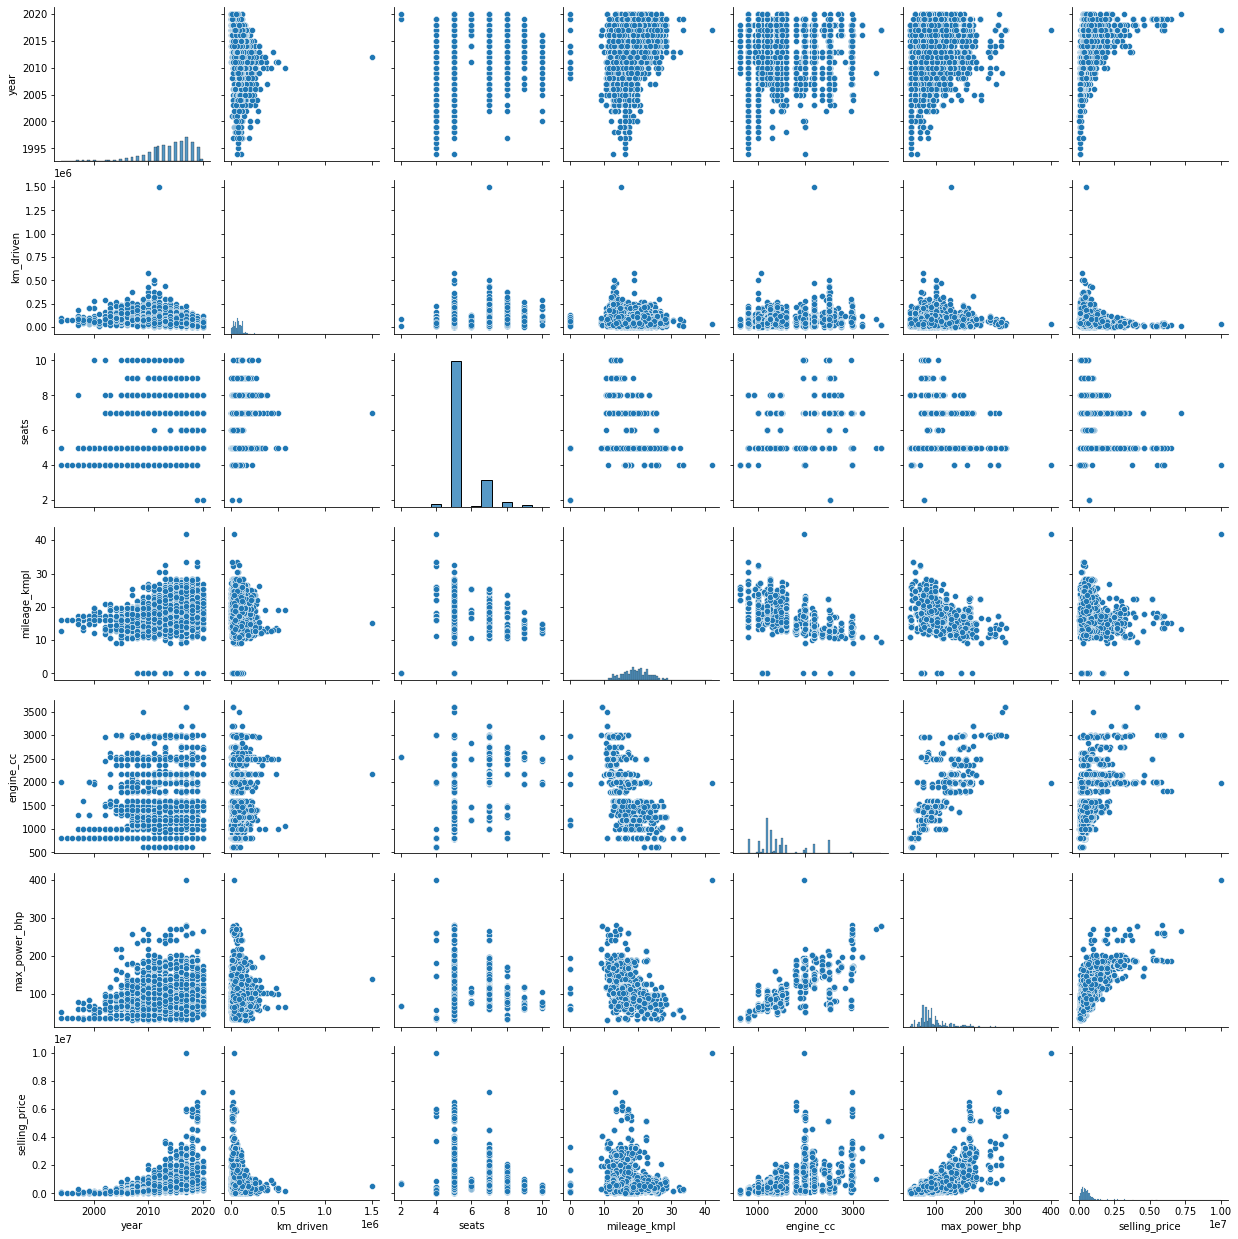

In [ ]:
sns.pairplot(df_train)

In [ ]:
df_train_copy = df_train

#copy df_train to another dataframe to be safe.

In [ ]:
X_train_copy = X_train
Y_train_copy = Y_train

#copy training sets to another dataframe.

In [ ]:
corr_train = df_train.corr()
corr_train

#show correlation in amongnst features.

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,selling_price
year,1.000000,-0.459729,-0.008522,0.329508,0.006410,0.214944,0.409325
km_driven,-0.459729,1.000000,0.253887,-0.194217,0.239889,-0.030954,-0.238307
seats,-0.008522,0.253887,1.000000,-0.461309,0.623117,0.201508,0.049050
mileage_kmpl,0.329508,-0.194217,-0.461309,1.000000,-0.578197,-0.369141,-0.119040
engine_cc,0.006410,0.239889,0.623117,-0.578197,1.000000,0.699012,0.449068
max_power_bhp,0.214944,-0.030954,0.201508,-0.369141,0.699012,1.000000,0.741243
selling_price,0.409325,-0.238307,0.049050,-0.119040,0.449068,0.741243,1.000000


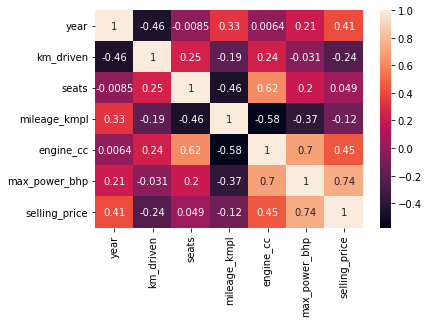

In [ ]:
sns.heatmap(corr_train, annot=True)

There are correlations between certain features.
1. Max Power and Engine
2. There are little correlations between the selling price and these attributes (max power, engine, year).

Pre Processing 

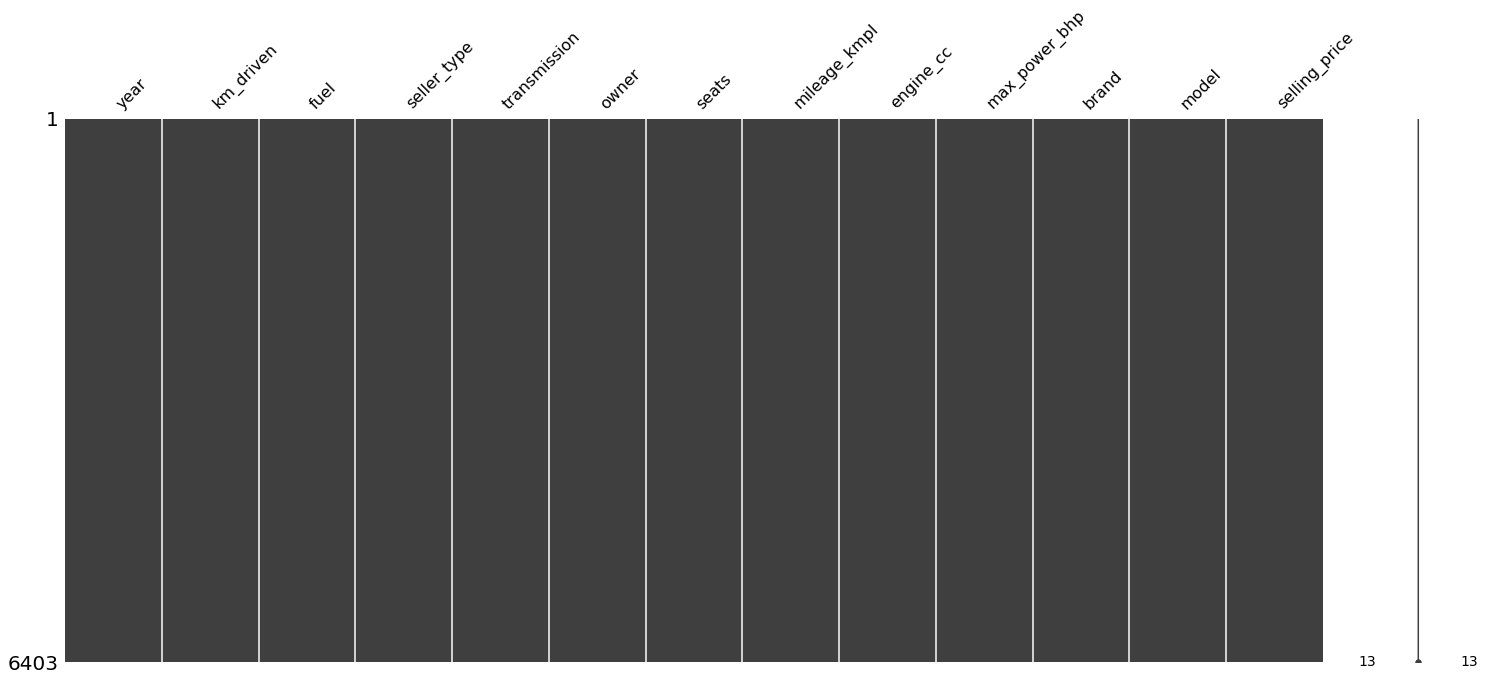

In [ ]:
msno.matrix(df_train)

In [ ]:
X_train_copy = pd.get_dummies(data= X_train, columns=['fuel','seller_type','transmission','owner','brand','model'])
#encode categorical attributes

In [ ]:
X_train_copy.head()

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,...,model_i20 Magna 1.4 CRDi,model_i20 Magna 1.4 CRDi (Diesel),model_i20 Magna Optional 1.2,model_i20 Magna Optional 1.4 CRDi,model_i20 Petrol CVT Asta,model_i20 Sportz 1.2,model_i20 Sportz 1.4 CRDi,model_i20 Sportz AT 1.4,model_i20 Sportz Option 1.2,model_i20 Sportz Option 1.4 CRDi
5479,2017,60000,5.0,28.40,1248.0,74.02,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4289,2016,90000,5.0,19.09,1405.0,69.01,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3327,2011,65000,5.0,18.90,998.0,67.10,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6629,2019,80000,2.0,0.00,2523.0,70.00,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3917,2018,30000,5.0,21.50,1497.0,108.50,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#scale data using mix_max

In [ ]:
# Apply scaler() to all the columns except the 'dummy' variables
num_vars = ['year', 'km_driven', 'seats', 'mileage_kmpl', 'engine_cc', 'max_power_bhp']

X_train_copy[num_vars] = scaler.fit_transform(X_train_copy[num_vars])

In [ ]:
X_train_copy.head()

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,...,model_i20 Magna 1.4 CRDi,model_i20 Magna 1.4 CRDi (Diesel),model_i20 Magna Optional 1.2,model_i20 Magna Optional 1.4 CRDi,model_i20 Petrol CVT Asta,model_i20 Sportz 1.2,model_i20 Sportz 1.4 CRDi,model_i20 Sportz AT 1.4,model_i20 Sportz Option 1.2,model_i20 Sportz Option 1.4 CRDi
5479,0.884615,0.039999,0.375,0.676190,0.209396,0.112255,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4289,0.846154,0.059999,0.375,0.454524,0.262081,0.098611,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3327,0.653846,0.043333,0.375,0.450000,0.125503,0.093410,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6629,0.961538,0.053333,0.000,0.000000,0.637248,0.101307,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3917,0.923077,0.019999,0.375,0.511905,0.292953,0.206155,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train_copy.head()

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,...,model_i20 Magna 1.4 CRDi,model_i20 Magna 1.4 CRDi (Diesel),model_i20 Magna Optional 1.2,model_i20 Magna Optional 1.4 CRDi,model_i20 Petrol CVT Asta,model_i20 Sportz 1.2,model_i20 Sportz 1.4 CRDi,model_i20 Sportz AT 1.4,model_i20 Sportz Option 1.2,model_i20 Sportz Option 1.4 CRDi
5479,0.884615,0.039999,0.375,0.676190,0.209396,0.112255,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4289,0.846154,0.059999,0.375,0.454524,0.262081,0.098611,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3327,0.653846,0.043333,0.375,0.450000,0.125503,0.093410,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6629,0.961538,0.053333,0.000,0.000000,0.637248,0.101307,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3917,0.923077,0.019999,0.375,0.511905,0.292953,0.206155,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# loading the lasso regression model
lassreg_train = Lasso()

In [ ]:
lassreg_train.fit(X_train_copy,Y_train_copy)

#fit model to training set.

/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.251e+13, tolerance: 4.018e+11
  model = cd_fast.enet_coordinate_descent(


Lasso()

In [ ]:
# prediction on Training data
training_data_prediction = lassreg_train.predict(X_train_copy)

# R squared Error, MSE, MAE.
error_score = metrics.r2_score(Y_train_copy, training_data_prediction)
error_score_mse = metrics.mean_squared_error(Y_train_copy, training_data_prediction)
error_score_mae = metrics.mean_absolute_error(Y_train_copy, training_data_prediction)

print("R squared Error : ", error_score)
print("MSE: ", error_score_mse)
print("MAE: ", error_score_mae)

R squared Error :  0.9885208639912011
MSE:  7202954149.842362
MAE:  44790.38523271318


Validation Preprocess

In [ ]:
X_val_copy = X_val
Y_val_copy = Y_val

In [ ]:
X_val_copy.head()

,year,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model
1288,2004,113000,Petrol,Individual,Manual,Second Owner,5.0,19.70,796.0,46.3,Maruti,Alto LX
2076,2013,90000,Petrol,Individual,Manual,First Owner,5.0,22.74,796.0,47.3,Maruti,Alto 800 LX
6047,2010,110000,Diesel,Individual,Manual,Third Owner,5.0,17.80,1399.0,68.0,Ford,Fiesta 1.4 ZXi TDCi LE
1021,2008,120000,Petrol,Individual,Manual,Second Owner,5.0,17.00,1497.0,118.0,Honda,City 1.5 E MT
7898,2017,120000,Diesel,Individual,Manual,First Owner,7.0,24.52,1248.0,88.5,Maruti,Ertiga SHVS ZDI Plus


In [ ]:
X_val_copy = pd.get_dummies(data= X_val, columns=['fuel','seller_type','transmission','owner','brand','model'])

In [ ]:
scaler_X= MinMaxScaler()

In [ ]:
# Apply scaler() to all the columns except the 'dummy' variables
num_vars = ['year', 'km_driven', 'seats', 'mileage_kmpl', 'engine_cc', 'max_power_bhp']

X_val_copy[num_vars] = scaler_X.fit_transform(X_val_copy[num_vars])

In [ ]:
X_val_copy.head()

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,...,model_i20 2015-2017 Sportz 1.2,model_i20 2015-2017 Sportz Option 1.4 CRDi,model_i20 Asta 1.2,model_i20 Asta Option 1.4 CRDi,model_i20 Magna,model_i20 Magna 1.4 CRDi,model_i20 Sportz 1.2,model_i20 Sportz 1.4 CRDi,model_i20 Sportz Diesel,model_i20 Sportz Option 1.2
1288,0.333333,0.302578,0.2,0.539683,0.057718,0.049227,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2076,0.708333,0.240163,0.2,0.700529,0.057718,0.053295,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6047,0.583333,0.294437,0.2,0.439153,0.260067,0.137510,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1021,0.500000,0.321574,0.2,0.396825,0.292953,0.340928,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7898,0.875000,0.321574,0.6,0.794709,0.209396,0.220911,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# loading the lasso regression model
lassreg_val = Lasso()

In [ ]:
lassreg_val.fit(X_val_copy,Y_val_copy)

/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.195e+11, tolerance: 6.463e+10
  model = cd_fast.enet_coordinate_descent(


Lasso()

In [ ]:
# prediction on validation set
training_data_prediction = lassreg_val.predict(X_val_copy)

# R squared Error
error_score = metrics.r2_score(Y_val_copy, training_data_prediction)
error_score_mse = metrics.mean_squared_error(Y_val_copy, training_data_prediction)
error_score_mae = metrics.mean_absolute_error(Y_val_copy, training_data_prediction)

print("R squared Error : ", error_score)
print("MSE: ", error_score_mse)
print("MAE: ", error_score_mae)

R squared Error :  0.998259685928229
MSE:  1579773337.913597
MAE:  18690.890191634408


In [ ]:
accuracy_train=lassreg_train.score(X_train_copy,Y_train_copy)
print('Training Accuracy: ',round(accuracy_train*100, 2),'%')

Training Accuracy:  98.85 %


In [ ]:
accuracy_val=lassreg_val.score(X_val_copy,Y_val_copy)
print('Validation Accuracy: ',round(accuracy_val*100, 2),'%')

Validation Accuracy:  99.83 %


iteration 2

In [ ]:
X_train_out = X_train
Y_train_out = Y_train

In [ ]:
X_train_out = pd.get_dummies(data= X_train_out, columns=['fuel','seller_type','transmission','owner','brand','model'])
#encode categorical attributes

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler_two= MinMaxScaler()
#scale data using mix_max